# ⭐ Day 15: Pandas Grouping, Aggregation & Pivot Tables
Extracting Insights from Data for AI & ML | Step-by-Step Tutorial with Examples & Exercises

*Day 15 of 369-day Python & AI Learning Path*

## 💡 Introduction

Welcome to Day 15 of your Python & AI Learning Journey! Today we're diving deep into one of the most powerful features of Pandas: **grouping, aggregation, and pivot tables**. These techniques are absolutely essential for anyone working in data science, machine learning, or AI.

**Why are these skills crucial for AI/ML?**

1. **Feature Engineering**: Group-wise statistics often become powerful features. For example, knowing the average sales per region or the median performance per category can significantly improve model predictions.

2. **Understanding Data Distributions**: Before building models, you need to understand how your data varies across different groups. Grouping reveals patterns that aggregate statistics hide.

3. **Target Encoding**: In machine learning, encoding categorical variables based on group-wise target means is a common and effective technique.

4. **Data Quality Assessment**: Grouping helps identify outliers and anomalies within specific segments of your data, leading to better preprocessing decisions.

5. **Business Intelligence**: Creating summary tables and reports is a daily task for data professionals. Pivot tables make this elegant and efficient.

By the end of this tutorial, you'll be able to slice, dice, and summarize data like a pro, extracting actionable insights that drive better AI models and business decisions. Let's get started!

## 📌 Table of Contents

1. [Setting Up & Creating Sample Data](#setup)
2. [GroupBy Basics: Split-Apply-Combine](#groupby-basics)
3. [Aggregation Functions](#aggregation)
4. [Multi-Column Grouping](#multi-column)
5. [Named Aggregations](#named-agg)
6. [Transformation with .transform()](#transform)
7. [Filtering Groups](#filtering)
8. [Applying Custom Functions with .apply()](#apply)
9. [Pivot Tables](#pivot-tables)
10. [Cross-Tabulation](#crosstab)
11. [Real AI/ML Examples](#ml-examples)
12. [🛠️ Hands-On Exercises](#exercises)
13. [Solutions](#solutions)

## 1. Setting Up & Creating Sample Data {#setup}

Let's create a realistic dataset representing an e-commerce scenario with customers, products, and sales data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Create a realistic e-commerce dataset
np.random.seed(42)
n_records = 500

data = {
    'customer_id': np.random.randint(1000, 1100, n_records),
    'product_category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Sports', 'Books'], n_records),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_records),
    'purchase_amount': np.random.normal(150, 80, n_records).clip(20, 500),
    'quantity': np.random.randint(1, 5, n_records),
    'satisfaction_score': np.random.randint(1, 6, n_records),
    'month': np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], n_records),
    'is_returning_customer': np.random.choice([True, False], n_records, p=[0.4, 0.6])
}

df = pd.DataFrame(data)
df['purchase_amount'] = df['purchase_amount'].round(2)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (500, 8)

First 5 rows:


,customer_id,product_category,region,purchase_amount,quantity,satisfaction_score,month,is_returning_customer
0,1051,Sports,North,161.78,4,3,Jun,False
1,1092,Clothing,East,132.20,1,1,May,False
2,1014,Home,East,215.95,2,4,Mar,False
3,1071,Books,West,140.03,3,5,Jun,True
4,1060,Electronics,South,209.84,2,5,Apr,False


## 2. GroupBy Basics: Split-Apply-Combine {#groupby-basics}

The GroupBy mechanism follows the **Split-Apply-Combine** strategy:
- **Split**: Break data into groups based on criteria
- **Apply**: Apply a function to each group independently
- **Combine**: Combine results into a new data structure

In [2]:
# Basic groupby: Average purchase by category
category_means = df.groupby('product_category')['purchase_amount'].mean()
print("Average Purchase Amount by Category:")
print(category_means.round(2))

# Multiple statistics at once
print("\n" + "="*50)
print("Multiple stats by region:")
region_stats = df.groupby('region')['purchase_amount'].agg(['mean', 'sum', 'count', 'std'])
print(region_stats.round(2))

Average Purchase Amount by Category:
product_category
Books          166.85
Clothing       159.67
Electronics    167.01
Home           147.12
Sports         162.25
Name: purchase_amount, dtype: float64

Multiple stats by region:
          mean       sum  count    std
region                                
East    153.98  20017.17    130  83.21
North   157.05  20259.71    129  81.86
South   163.58  21102.31    129  84.93
West    170.86  19136.88    112  81.01


### Visualizing Group Statistics

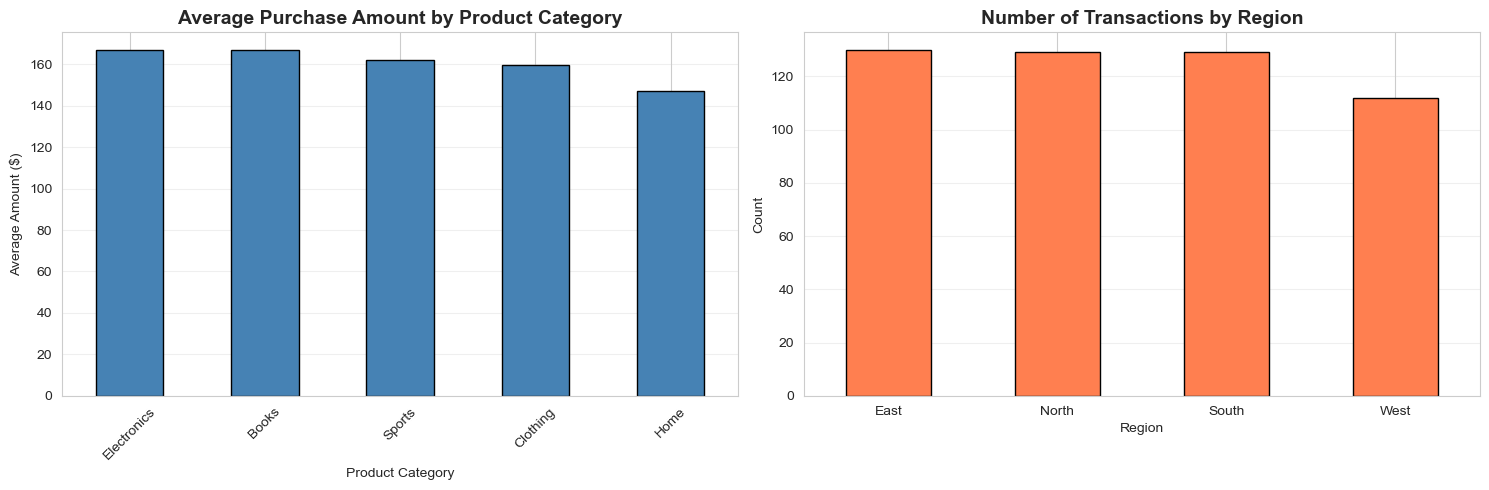

In [3]:
# Bar plot of average purchase by category
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Mean purchase by category
category_means = df.groupby('product_category')['purchase_amount'].mean().sort_values(ascending=False)
category_means.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Average Purchase Amount by Product Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Amount ($)')
axes[0].set_xlabel('Product Category')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Count of transactions by region
region_counts = df.groupby('region').size()
region_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Number of Transactions by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Region')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Aggregation Functions {#aggregation}

Pandas provides many built-in aggregation functions. You can also use `.agg()` to apply multiple functions simultaneously.

In [4]:
# Comprehensive aggregation
agg_results = df.groupby('product_category').agg({
    'purchase_amount': ['mean', 'median', 'min', 'max', 'std'],
    'quantity': ['sum', 'mean'],
    'satisfaction_score': ['mean', 'count']
})

print("Comprehensive Aggregation by Category:")
print(agg_results.round(2))

# Flatten column names for easier access
agg_results.columns = ['_'.join(col).strip() for col in agg_results.columns.values]
print("\nFlattened column names:")
print(agg_results.columns.tolist())

Comprehensive Aggregation by Category:
                 purchase_amount                              quantity        \
                            mean  median   min     max    std      sum  mean   
product_category                                                               
Books                     166.85  162.59  20.0  398.39  87.38      279  2.51   
Clothing                  159.67  155.24  20.0  357.82  81.65      237  2.32   
Electronics               167.01  168.37  20.0  353.68  81.72      242  2.35   
Home                      147.12  144.22  20.0  358.48  77.07      244  2.74   
Sports                    162.25  157.17  20.0  403.39  85.09      253  2.66   

                 satisfaction_score        
                               mean count  
product_category                           
Books                          3.33   111  
Clothing                       2.97   102  
Electronics                    2.95   103  
Home                           3.08    89  
Sports      

## 4. GroupBy with Multiple Columns {#multi-column}

Group by multiple columns to analyze interactions between categories.

Average Purchase by Category and Region:
region              East   North   South    West
product_category                                
Books             185.17  195.94  135.53  158.86
Clothing          139.95  143.85  186.04  165.21
Electronics       152.44  160.24  184.94  173.93
Home              132.34  154.42  125.93  172.71
Sports            146.90  137.49  181.72  187.90


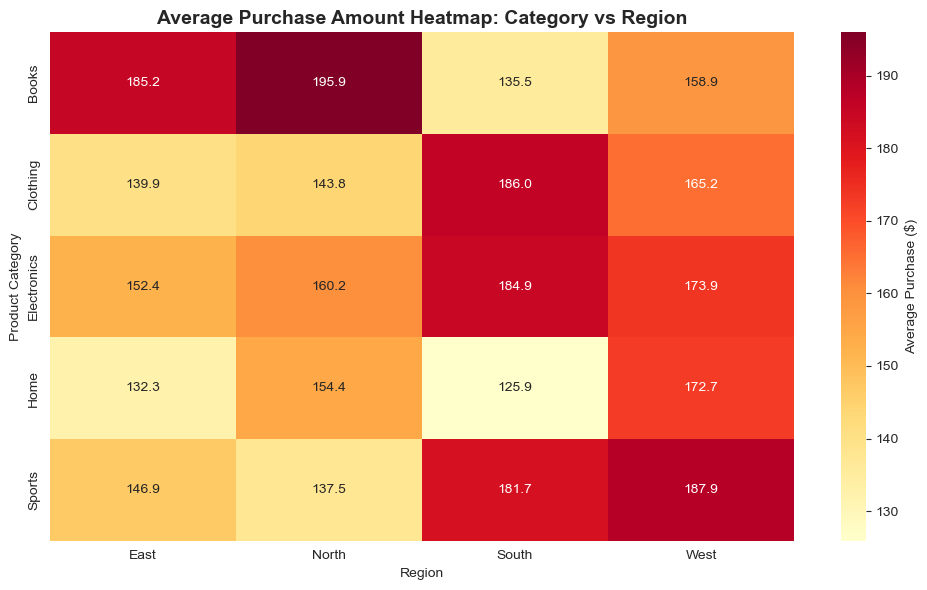

In [5]:
# Group by category AND region
multi_group = df.groupby(['product_category', 'region'])['purchase_amount'].mean().unstack()
print("Average Purchase by Category and Region:")
print(multi_group.round(2))

# Heatmap visualization
plt.figure(figsize=(10, 6))
sns.heatmap(multi_group, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Average Purchase ($)'})
plt.title('Average Purchase Amount Heatmap: Category vs Region', fontsize=14, fontweight='bold')
plt.ylabel('Product Category')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

## 5. Named Aggregations {#named-agg}

Modern Pandas (0.25+) supports named aggregations for cleaner syntax.

In [6]:
# Named aggregation - much cleaner!
named_agg = df.groupby('product_category').agg(
    avg_purchase=('purchase_amount', 'mean'),
    total_revenue=('purchase_amount', 'sum'),
    total_quantity=('quantity', 'sum'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    customer_count=('customer_id', 'nunique')
).round(2)

print("Named Aggregation Results:")
print(named_agg)

# Sort by total revenue
print("\nSorted by Total Revenue:")
print(named_agg.sort_values('total_revenue', ascending=False))

Named Aggregation Results:
                  avg_purchase  total_revenue  total_quantity  \
product_category                                                
Books                   166.85       18520.22             279   
Clothing                159.67       16286.54             237   
Electronics             167.01       17201.56             242   
Home                    147.12       13094.09             244   
Sports                  162.25       15413.66             253   

                  avg_satisfaction  customer_count  
product_category                                    
Books                         3.33              62  
Clothing                      2.97              60  
Electronics                   2.95              63  
Home                          3.08              58  
Sports                        2.84              59  

Sorted by Total Revenue:
                  avg_purchase  total_revenue  total_quantity  \
product_category                                       

## 6. Transformation with .transform() {#transform}

`.transform()` returns an object with the same shape as the original, perfect for creating new features based on group statistics.

In [7]:
# Create new features using transform
# Feature 1: Deviation from category average
df['purchase_vs_category_avg'] = df['purchase_amount'] - df.groupby('product_category')['purchase_amount'].transform('mean')

# Feature 2: Percentile rank within category
df['category_percentile'] = df.groupby('product_category')['purchase_amount'].transform(
    lambda x: pd.Series(x).rank(pct=True)
)

# Feature 3: Z-score within region
df['regional_zscore'] = df.groupby('region')['purchase_amount'].transform(
    lambda x: (x - x.mean()) / x.std()
)

print("New features created:")
print(df[['product_category', 'purchase_amount', 'purchase_vs_category_avg', 
          'category_percentile', 'regional_zscore']].head(10).round(3))

New features created:
  product_category  purchase_amount  purchase_vs_category_avg  \
0           Sports           161.78                    -0.469   
1         Clothing           132.20                   -27.472   
2             Home           215.95                    68.825   
3            Books           140.03                   -26.819   
4      Electronics           209.84                    42.835   
5            Books           270.08                   103.231   
6           Sports           139.78                   -22.469   
7            Books           194.41                    27.561   
8      Electronics            20.00                  -147.005   
9           Sports           140.09                   -22.159   

   category_percentile  regional_zscore  
0                0.547            0.058  
1                0.412           -0.262  
2                0.820            0.745  
3                0.396           -0.381  
4                0.680            0.545  
5         

## 7. Filtering Groups with .filter() {#filtering}

Use `.filter()` to keep only groups that meet certain criteria.

In [8]:
# Keep only categories with more than 90 transactions
popular_categories = df.groupby('product_category').filter(lambda x: len(x) > 90)
print(f"Original dataset: {len(df)} rows")
print(f"After filtering (categories > 90 transactions): {len(popular_categories)} rows")
print(f"Categories kept: {popular_categories['product_category'].unique().tolist()}")

# Filter regions with high average satisfaction
high_satisfaction_regions = df.groupby('region').filter(
    lambda x: x['satisfaction_score'].mean() > 3.0
)
print(f"\nRegions with avg satisfaction > 3.0: {high_satisfaction_regions['region'].unique().tolist()}")
print(f"Rows from high-satisfaction regions: {len(high_satisfaction_regions)}")

Original dataset: 500 rows
After filtering (categories > 90 transactions): 411 rows
Categories kept: ['Sports', 'Clothing', 'Books', 'Electronics']

Regions with avg satisfaction > 3.0: ['North', 'West']
Rows from high-satisfaction regions: 241


## 8. Applying Custom Functions with .apply() {#apply}

For complex operations that don't fit built-in functions, use `.apply()`.

In [9]:
# Custom function: Top 2 purchases per category
def top_n_purchases(group, n=2):
    return group.nlargest(n, 'purchase_amount')[['customer_id', 'purchase_amount', 'satisfaction_score']]

top_purchases = df.groupby('product_category', group_keys=False).apply(top_n_purchases, n=2)
print("Top 2 Purchases per Category:")
print(top_purchases)

# Custom aggregation: Range and IQR
def custom_stats(group):
    return pd.Series({
        'range': group.max() - group.min(),
        'iqr': group.quantile(0.75) - group.quantile(0.25),
        'cv': group.std() / group.mean()  # Coefficient of variation
    })

custom_results = df.groupby('product_category')['purchase_amount'].apply(custom_stats).unstack()
print("\nCustom Statistics by Category:")
print(custom_results.round(3))

Top 2 Purchases per Category:
     customer_id  purchase_amount  satisfaction_score
278         1088           398.39                   3
55          1008           369.35                   5
72          1001           357.82                   5
324         1040           325.18                   5
444         1057           353.68                   3
426         1015           346.46                   1
39          1046           358.48                   5
392         1057           326.98                   4
109         1070           403.39                   4
423         1019           337.76                   3

Custom Statistics by Category:
                   range      iqr     cv
product_category                        
Books             378.39  106.415  0.524
Clothing          337.82  131.858  0.511
Electronics       333.68  106.625  0.489
Home              338.48  108.910  0.524
Sports            383.39  106.275  0.524


## 9. Pivot Tables {#pivot-tables}

Pivot tables are a powerful way to summarize data, similar to Excel pivot tables.

In [10]:
# Basic pivot table
pivot1 = pd.pivot_table(df, 
                       values='purchase_amount', 
                       index='product_category', 
                       columns='region', 
                       aggfunc='mean',
                       margins=True,  # Add row/column totals
                       margins_name='Overall')
print("Pivot Table: Average Purchase by Category and Region")
print(pivot1.round(2))

# Advanced pivot with multiple values and agg functions
pivot2 = pd.pivot_table(df,
                       values=['purchase_amount', 'satisfaction_score'],
                       index=['region', 'is_returning_customer'],
                       columns='product_category',
                       aggfunc={'purchase_amount': 'sum', 'satisfaction_score': 'mean'},
                       fill_value=0)
print("\nAdvanced Pivot: Revenue and Satisfaction by Region & Customer Type")
print(pivot2.round(2))

Pivot Table: Average Purchase by Category and Region
region              East   North   South    West  Overall
product_category                                         
Books             185.17  195.94  135.53  158.86   166.85
Clothing          139.95  143.85  186.04  165.21   159.67
Electronics       152.44  160.24  184.94  173.93   167.01
Home              132.34  154.42  125.93  172.71   147.12
Sports            146.90  137.49  181.72  187.90   162.25
Overall           153.98  157.05  163.58  170.86   161.03

Advanced Pivot: Revenue and Satisfaction by Region & Customer Type
                             purchase_amount                                \
product_category                       Books Clothing Electronics     Home   
region is_returning_customer                                                 
East   False                         4271.57  2594.91     2547.62  2203.97   
       True                          1839.04  1043.67     1415.70   575.11   
North  False             

### Pivot Table Visualization

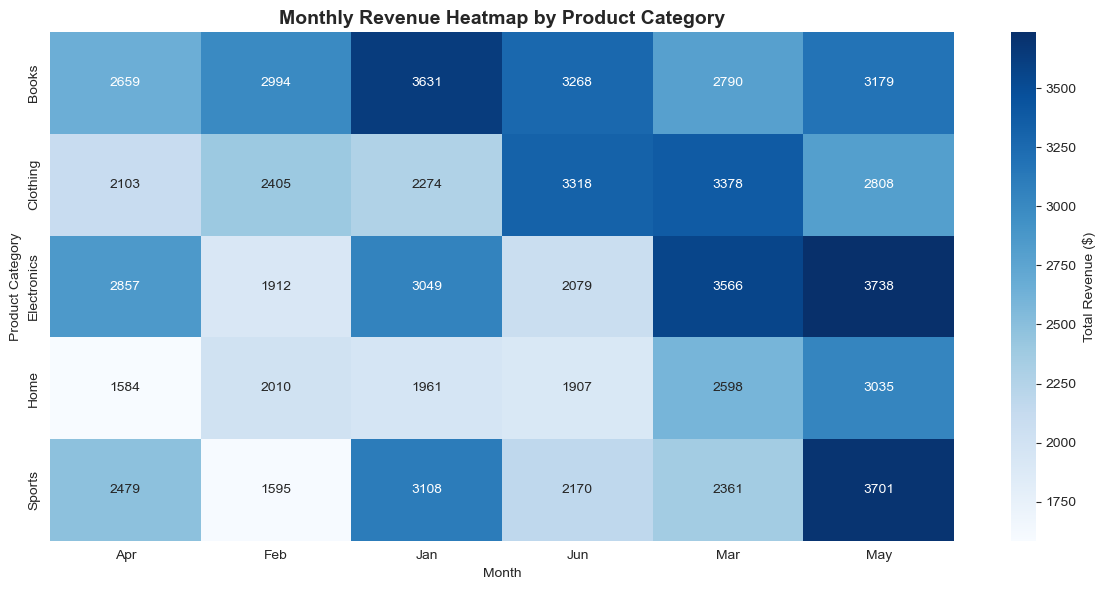

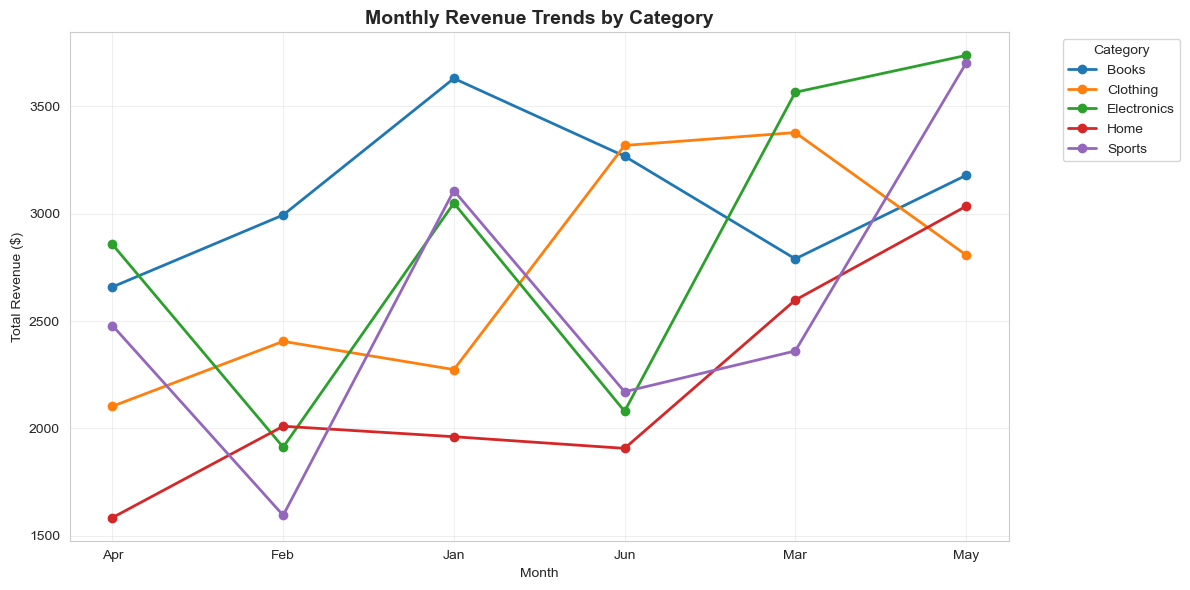

In [11]:
# Create a heatmap of the pivot table
pivot_for_viz = pd.pivot_table(df, 
                              values='purchase_amount', 
                              index='product_category', 
                              columns='month', 
                              aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_for_viz, annot=True, fmt='.0f', cmap='Blues', 
            cbar_kws={'label': 'Total Revenue ($)'})
plt.title('Monthly Revenue Heatmap by Product Category', fontsize=14, fontweight='bold')
plt.ylabel('Product Category')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

# Line plot showing trends
monthly_trends = df.groupby(['month', 'product_category'])['purchase_amount'].sum().unstack()
monthly_trends.plot(kind='line', marker='o', figsize=(12, 6), linewidth=2)
plt.title('Monthly Revenue Trends by Category', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Month')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Crosstab: pd.crosstab() for Categorical Analysis {#crosstab}

`pd.crosstab()` is specialized for frequency analysis of categorical variables.

Cross-Tabulation: Category vs Region (Counts)
region            East  North  South  West  All
product_category                               
Books               33     20     31    27  111
Clothing            26     23     28    25  102
Electronics         26     33     27    17  103
Home                21     27     20    21   89
Sports              24     26     23    22   95
All                130    129    129   112  500

Normalized Cross-Tab (Row Percentages):
region            East  North  South  West
product_category                          
Books             29.7   18.0   27.9  24.3
Clothing          25.5   22.5   27.5  24.5
Electronics       25.2   32.0   26.2  16.5
Home              23.6   30.3   22.5  23.6
Sports            25.3   27.4   24.2  23.2

Cross-Tab with Average Purchase Amount:
region              East   North   South    West
product_category                                
Books             185.17  195.94  135.53  158.86
Clothing          139.95  143.85  186.04

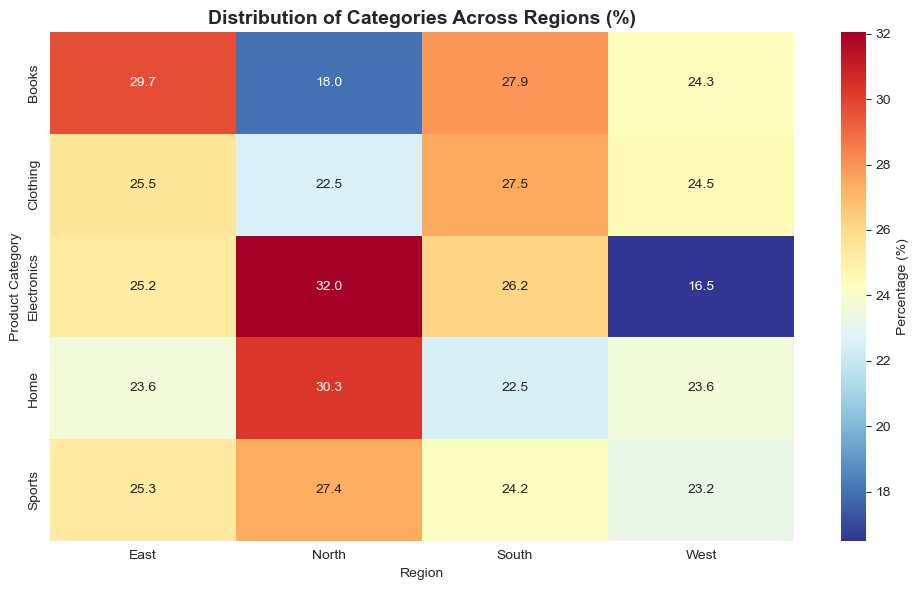

In [12]:
# Basic crosstab: frequency table
crosstab1 = pd.crosstab(df['product_category'], df['region'], margins=True)
print("Cross-Tabulation: Category vs Region (Counts)")
print(crosstab1)

# Normalized crosstab (percentages)
crosstab_pct = pd.crosstab(df['product_category'], df['region'], normalize='index') * 100
print("\nNormalized Cross-Tab (Row Percentages):")
print(crosstab_pct.round(1))

# Crosstab with values aggregation
crosstab_values = pd.crosstab(df['product_category'], 
                              df['region'], 
                              values=df['purchase_amount'], 
                              aggfunc='mean')
print("\nCross-Tab with Average Purchase Amount:")
print(crosstab_values.round(2))

# Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Percentage (%)'})
plt.title('Distribution of Categories Across Regions (%)', fontsize=14, fontweight='bold')
plt.ylabel('Product Category')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

## 11. Real AI/ML Examples {#ml-examples}

Let's explore how these techniques apply directly to machine learning workflows.

In [13]:
# ML Example 1: Group-wise Mean Target Encoding Preview
# Replace categorical variable with mean target value per category
target_mean = df.groupby('product_category')['satisfaction_score'].mean()
df['category_target_encoded'] = df['product_category'].map(target_mean)

print("Target Encoding Example:")
print(df[['product_category', 'category_target_encoded']].drop_duplicates().sort_values('category_target_encoded'))

# ML Example 2: Sales or Performance by Category (for reporting)
sales_by_category = df.groupby('product_category').agg(
    total_sales=('purchase_amount', 'sum'),
    avg_order_value=('purchase_amount', 'mean'),
    total_orders=('purchase_amount', 'count'),
    avg_satisfaction=('satisfaction_score', 'mean')
).round(2)

print("\nSales Performance by Category:")
print(sales_by_category)

# ML Example 3: Feature Statistics per Group
feature_stats = df.groupby('region').agg({
    'purchase_amount': ['mean', 'std', 'min', 'max'],
    'quantity': ['mean', 'sum'],
    'satisfaction_score': ['mean', 'std']
}).round(2)
print("\nFeature Statistics by Region:")
print(feature_stats)

# ML Example 4: Creating Summary Tables for Reports
summary_report = df.pivot_table(
    values=['purchase_amount', 'satisfaction_score'],
    index='product_category',
    columns='region',
    aggfunc={'purchase_amount': 'sum', 'satisfaction_score': 'mean'},
    margins=True
).round(2)
print("\nExecutive Summary Report:")
print(summary_report)

Target Encoding Example:
  product_category  category_target_encoded
0           Sports                 2.842105
4      Electronics                 2.951456
1         Clothing                 2.970588
2             Home                 3.078652
3            Books                 3.333333

Sales Performance by Category:
                  total_sales  avg_order_value  total_orders  avg_satisfaction
product_category                                                              
Books                18520.22           166.85           111              3.33
Clothing             16286.54           159.67           102              2.97
Electronics          17201.56           167.01           103              2.95
Home                 13094.09           147.12            89              3.08
Sports               15413.66           162.25            95              2.84

Feature Statistics by Region:
       purchase_amount                      quantity      satisfaction_score  \
               

### Advanced ML: Creating Aggregate Features for ML Models

Customer-Level Features for ML:
             total_spent  avg_purchase  purchase_count  categories_bought  \
customer_id                                                                 
1000             1311.54        145.73               9                  4   
1001             1323.84        132.38              10                  5   
1002             1200.77        171.54               7                  4   
1003              500.53        100.11               5                  4   
1004              370.58        123.53               3                  3   
1005              435.32        108.83               4                  3   
1006              837.81        167.56               5                  5   
1007             1120.17        160.02               7                  4   
1008             1367.33        195.33               7                  4   
1010              509.24        169.75               3                  2   

             avg_satisfaction favorite_cate

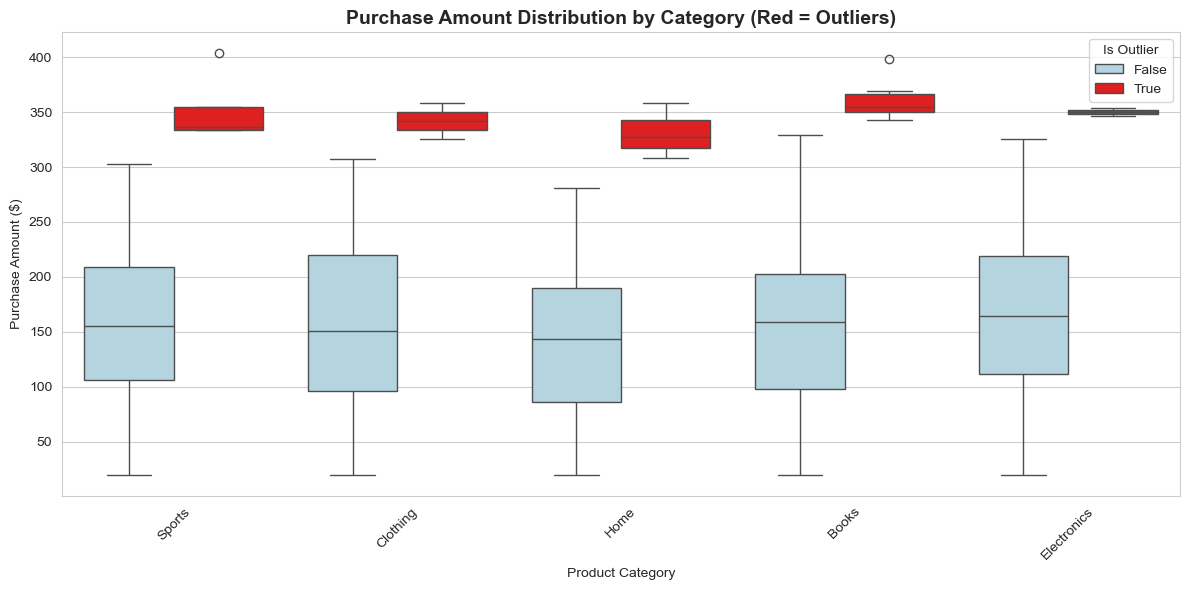


Target Variable Analysis by Category:
                   mean    std  count  target_std_error
product_category                                       
Books             3.333  1.461    111             0.139
Clothing          2.971  1.293    102             0.128
Electronics       2.951  1.331    103             0.131
Home              3.079  1.440     89             0.153
Sports            2.842  1.454     95             0.149


In [14]:
# ML Example 5: Creating aggregate features for customer segmentation
customer_features = df.groupby('customer_id').agg(
    total_spent=('purchase_amount', 'sum'),
    avg_purchase=('purchase_amount', 'mean'),
    purchase_count=('purchase_amount', 'count'),
    categories_bought=('product_category', 'nunique'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    favorite_category=('product_category', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
).round(2)

print("Customer-Level Features for ML:")
print(customer_features.head(10))

# ML Example 6: Group-wise outlier detection using z-scores
df['is_outlier'] = df.groupby('product_category')['purchase_amount'].transform(
    lambda x: np.abs((x - x.mean()) / x.std()) > 2
)
print(f"\nOutliers detected: {df['is_outlier'].sum()} transactions ({df['is_outlier'].mean()*100:.1f}%)")

# Boxplot to visualize outliers by category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='product_category', y='purchase_amount', hue='is_outlier', 
            palette={False: 'lightblue', True: 'red'})
plt.title('Purchase Amount Distribution by Category (Red = Outliers)', fontsize=14, fontweight='bold')
plt.ylabel('Purchase Amount ($)')
plt.xlabel('Product Category')
plt.xticks(rotation=45)
plt.legend(title='Is Outlier')
plt.tight_layout()
plt.show()

# ML Example 7: Analyzing target variable by groups
target_analysis = df.groupby('product_category')['satisfaction_score'].agg(['mean', 'std', 'count'])
target_analysis['target_std_error'] = target_analysis['std'] / np.sqrt(target_analysis['count'])
print("\nTarget Variable Analysis by Category:")
print(target_analysis.round(3))

## 🛠️ Hands-On Exercises

Complete these exercises to solidify your understanding. Try to solve them without looking at the solutions!

### Exercise 1: Basic GroupBy and Mean/Median
Calculate the mean and median `purchase_amount` for each `region`. Sort the results by mean in descending order.

In [15]:
# your code here


### Exercise 2: Multiple Aggregations
For each `product_category`, calculate the total revenue (sum), average quantity, number of unique customers, and the standard deviation of satisfaction scores. Use named aggregations.

In [16]:
# your code here


### Exercise 3: GroupBy with Multiple Columns
Group by both `region` and `is_returning_customer` to find the average purchase amount. Then create a bar plot showing these averages.

In [17]:
# your code here


### Exercise 4: Custom Apply Functions
Write a custom function that calculates the percentage of high-value transactions (purchase > $200) for each product category. Apply this function using `.apply()` and display the results as percentages.

In [18]:
# your code here


### Exercise 5: Pivot Table Creation
Create a pivot table showing the **sum** of `purchase_amount` by `month` (rows) and `product_category` (columns). Add margins to show totals.

In [19]:
# your code here


### Exercise 6: Crosstab for Categorical Insights
Create a crosstab showing the count of transactions by `product_category` and `satisfaction_score` (1-5). Then normalize it to show row percentages and visualize as a heatmap.

In [20]:
# your code here


### Exercise 7: Creating New Aggregated Features for ML
Create a new column called `spending_rank_in_region` that ranks each customer's purchase amount within their region (1 = highest spender). Use `.transform()` with the `rank()` method.

In [21]:
# your code here


### Exercise 8: Filtering Groups
Filter the dataset to keep only product categories where the average satisfaction score is greater than 3.0 AND there are at least 80 transactions. How many rows remain?

In [22]:
# your code here


### Exercise 9: Analyzing Target Variable by Groups
Calculate the mean, standard deviation, and count of `satisfaction_score` for each `product_category`. Also calculate the standard error of the mean (std / sqrt(count)).

In [23]:
# your code here


### Exercise 10: Advanced ML Feature Creation
Create a customer-level summary table with these features:
- `total_spending`
- `avg_transaction_value`
- `purchase_frequency` (count of transactions)
- `category_diversity` (number of unique categories)
- `loyalty_score` (average satisfaction weighted by purchase amount)

Hint: For loyalty_score, you may need a custom lambda function.

In [24]:
# your code here


### Exercise 11: Time-Based Grouping
Group the data by `month` and calculate the month-over-month growth rate in total revenue. Handle the first month appropriately (show it as 0% or NaN).

In [25]:
# your code here


## Solutions (check after attempting)

Below are the solutions. Try the exercises first before looking here!

### Solution 1: Basic GroupBy and Mean/Median
Calculate the mean and median `purchase_amount` for each `region`. Sort the results by mean in descending order.

In [26]:
# Solution 1
result = df.groupby('region')['purchase_amount'].agg(['mean', 'median']).sort_values('mean', ascending=False)
print(result.round(2))

# Expected output: A DataFrame with regions as index, mean and median columns, sorted by mean descending

          mean  median
region                
West    170.86  166.14
South   163.58  148.07
North   157.05  160.01
East    153.98  146.12


### Solution 2: Multiple Aggregations
For each `product_category`, calculate the total revenue (sum), average quantity, number of unique customers, and the standard deviation of satisfaction scores. Use named aggregations.

In [27]:
# Solution 2
result = df.groupby('product_category').agg(
    total_revenue=('purchase_amount', 'sum'),
    avg_quantity=('quantity', 'mean'),
    unique_customers=('customer_id', 'nunique'),
    std_satisfaction=('satisfaction_score', 'std')
).round(2)
print(result)

# Expected output: DataFrame with 5 rows (categories) and 4 columns showing the requested metrics

                  total_revenue  avg_quantity  unique_customers  \
product_category                                                  
Books                  18520.22          2.51                62   
Clothing               16286.54          2.32                60   
Electronics            17201.56          2.35                63   
Home                   13094.09          2.74                58   
Sports                 15413.66          2.66                59   

                  std_satisfaction  
product_category                    
Books                         1.46  
Clothing                      1.29  
Electronics                   1.33  
Home                          1.44  
Sports                        1.45  


### Solution 3: GroupBy with Multiple Columns
Group by both `region` and `is_returning_customer` to find the average purchase amount. Then create a bar plot showing these averages.

is_returning_customer   False   True 
region                               
East                   164.87  133.41
North                  165.41  146.82
South                  177.85  144.39
West                   170.04  171.85


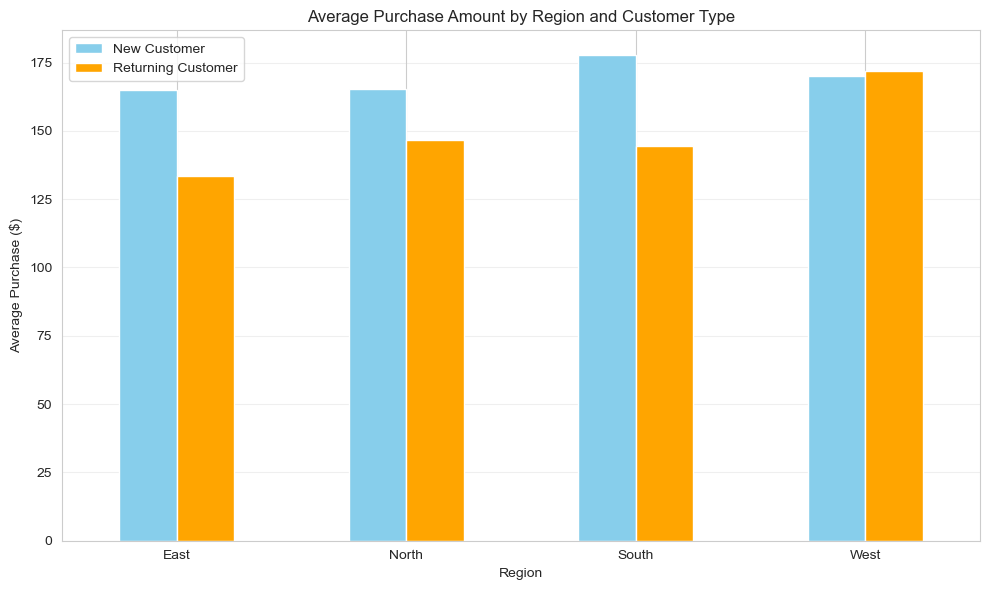

In [28]:
# Solution 3
result = df.groupby(['region', 'is_returning_customer'])['purchase_amount'].mean().unstack()
print(result.round(2))

# Plot
result.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'])
plt.title('Average Purchase Amount by Region and Customer Type')
plt.ylabel('Average Purchase ($)')
plt.xlabel('Region')
plt.legend(['New Customer', 'Returning Customer'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Expected: Bar chart showing 4 regions with 2 bars each (new vs returning)

### Solution 4: Custom Apply Functions
Write a custom function that calculates the percentage of high-value transactions (purchase > $200) for each product category. Apply this function using `.apply()` and display the results as percentages.

In [29]:
# Solution 4
def high_value_pct(group):
    return (group > 200).mean() * 100

result = df.groupby('product_category')['purchase_amount'].apply(high_value_pct)
print(result.round(1))

# Alternative with lambda
result2 = df.groupby('product_category')['purchase_amount'].apply(lambda x: (x > 200).mean() * 100)
print("\nLambda version:")
print(result2.round(1))

# Expected: Series showing percentage of transactions > $200 for each of 5 categories

product_category
Books          31.5
Clothing       32.4
Electronics    35.9
Home           22.5
Sports         32.6
Name: purchase_amount, dtype: float64

Lambda version:
product_category
Books          31.5
Clothing       32.4
Electronics    35.9
Home           22.5
Sports         32.6
Name: purchase_amount, dtype: float64


### Solution 5: Pivot Table Creation
Create a pivot table showing the **sum** of `purchase_amount` by `month` (rows) and `product_category` (columns). Add margins to show totals.

In [30]:
# Solution 5
pivot = pd.pivot_table(df, 
                      values='purchase_amount', 
                      index='month', 
                      columns='product_category', 
                      aggfunc='sum',
                      margins=True,
                      margins_name='Total')
print(pivot.round(2))

# Expected: 7 rows (6 months + Total) and 6 columns (5 categories + Total)

product_category     Books  Clothing  Electronics      Home    Sports  \
month                                                                   
Apr                2659.00   2102.90      2856.85   1584.03   2478.92   
Feb                2994.10   2405.30      1912.19   2009.86   1594.77   
Jan                3630.51   2273.81      3049.46   1960.97   3107.78   
Jun                3268.09   3318.18      2079.47   1906.70   2170.50   
Mar                2789.67   3378.19      3566.00   2597.83   2360.65   
May                3178.85   2808.16      3737.59   3034.70   3701.04   
Total             18520.22  16286.54     17201.56  13094.09  15413.66   

product_category     Total  
month                       
Apr               11681.70  
Feb               10916.22  
Jan               14022.53  
Jun               12742.94  
Mar               14692.34  
May               16460.34  
Total             80516.07  


### Solution 6: Crosstab for Categorical Insights
Create a crosstab showing the count of transactions by `product_category` and `satisfaction_score` (1-5). Then normalize it to show row percentages and visualize as a heatmap.

Raw Counts:
satisfaction_score   1   2   3   4   5
product_category                      
Books               20  14  17  29  31
Clothing            18  19  26  26  13
Electronics         18  23  24  22  16
Home                18  15  17  20  19
Sports              25  17  17  20  16

Row Percentages:
satisfaction_score     1     2     3     4     5
product_category                                
Books               18.0  12.6  15.3  26.1  27.9
Clothing            17.6  18.6  25.5  25.5  12.7
Electronics         17.5  22.3  23.3  21.4  15.5
Home                20.2  16.9  19.1  22.5  21.3
Sports              26.3  17.9  17.9  21.1  16.8


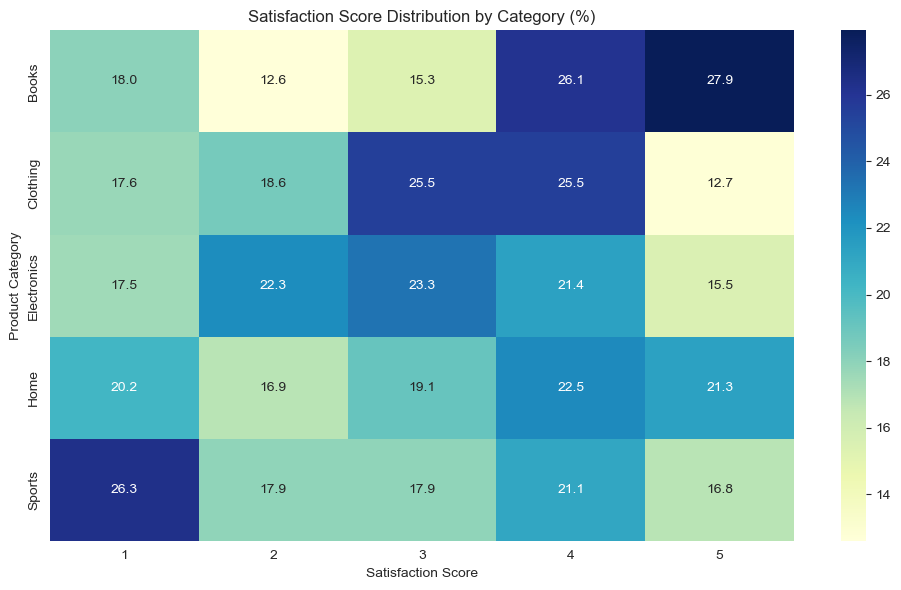

In [31]:
# Solution 6
# Raw counts
crosstab_counts = pd.crosstab(df['product_category'], df['satisfaction_score'])
print("Raw Counts:")
print(crosstab_counts)

# Row percentages
crosstab_pct = pd.crosstab(df['product_category'], df['satisfaction_score'], normalize='index') * 100
print("\nRow Percentages:")
print(crosstab_pct.round(1))

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Satisfaction Score Distribution by Category (%)')
plt.ylabel('Product Category')
plt.xlabel('Satisfaction Score')
plt.tight_layout()
plt.show()

# Expected: Heatmap showing percentage distribution of satisfaction scores (1-5) across categories

### Solution 7: Creating New Aggregated Features for ML
Create a new column called `spending_rank_in_region` that ranks each customer's purchase amount within their region (1 = highest spender). Use `.transform()` with the `rank()` method.

In [32]:
# Solution 7
df['spending_rank_in_region'] = df.groupby('region')['purchase_amount'].transform(
    lambda x: x.rank(ascending=False)
)

# Verify
print(df[['region', 'customer_id', 'purchase_amount', 'spending_rank_in_region']].head(10))

# Check ranks are correct within a region
print("\nRanks in 'North' region (should be 1 to N):")
print(df[df['region'] == 'North'][['purchase_amount', 'spending_rank_in_region']].sort_values('spending_rank_in_region').head(10))

# Expected: New column with ranks 1-N within each region, 1 being highest purchase amount

  region  customer_id  purchase_amount  spending_rank_in_region
0  North         1051           161.78                     63.0
1   East         1092           132.20                     72.0
2   East         1014           215.95                     28.0
3   West         1071           140.03                     71.0
4  South         1060           209.84                     32.0
5   East         1020           270.08                     15.0
6   East         1082           139.78                     69.0
7  South         1086           194.41                     40.0
8   East         1074            20.00                    127.0
9  North         1074           140.09                     77.0

Ranks in 'North' region (should be 1 to N):
     purchase_amount  spending_rank_in_region
39            358.48                      1.0
392           326.98                      2.0
62            313.39                      3.0
165           302.86                      4.0
369           295.23 

### Solution 8: Filtering Groups
Filter the dataset to keep only product categories where the average satisfaction score is greater than 3.0 AND there are at least 80 transactions. How many rows remain?

In [33]:
# Solution 8
filtered = df.groupby('product_category').filter(
    lambda x: (x['satisfaction_score'].mean() > 3.0) and (len(x) >= 80)
)

print(f"Original rows: {len(df)}")
print(f"Filtered rows: {len(filtered)}")
print(f"Categories kept: {filtered['product_category'].unique().tolist()}")

# Show which categories passed
summary = df.groupby('product_category').agg(
    avg_sat=('satisfaction_score', 'mean'),
    count=('satisfaction_score', 'count')
)
print("\nCategory Summary:")
print(summary)
print("\nCategories meeting criteria (avg > 3.0 AND count >= 80):")
print(summary[(summary['avg_sat'] > 3.0) & (summary['count'] >= 80)])

# Expected: Shows count of remaining rows and which categories passed the filter

Original rows: 500
Filtered rows: 200
Categories kept: ['Home', 'Books']

Category Summary:
                   avg_sat  count
product_category                 
Books             3.333333    111
Clothing          2.970588    102
Electronics       2.951456    103
Home              3.078652     89
Sports            2.842105     95

Categories meeting criteria (avg > 3.0 AND count >= 80):
                   avg_sat  count
product_category                 
Books             3.333333    111
Home              3.078652     89


### Solution 9: Analyzing Target Variable by Groups
Calculate the mean, standard deviation, and count of `satisfaction_score` for each `product_category`. Also calculate the standard error of the mean (std / sqrt(count)).

In [34]:
# Solution 9
target_analysis = df.groupby('product_category')['satisfaction_score'].agg(['mean', 'std', 'count'])
target_analysis['std_error'] = target_analysis['std'] / np.sqrt(target_analysis['count'])
target_analysis = target_analysis.round(3)
print(target_analysis)

# Expected: DataFrame with 5 rows and 4 columns (mean, std, count, std_error)

                   mean    std  count  std_error
product_category                                
Books             3.333  1.461    111      0.139
Clothing          2.971  1.293    102      0.128
Electronics       2.951  1.331    103      0.131
Home              3.079  1.440     89      0.153
Sports            2.842  1.454     95      0.149


### Solution 10: Advanced ML Feature Creation
Create a customer-level summary table with these features:
- `total_spending`
- `avg_transaction_value`
- `purchase_frequency` (count of transactions)
- `category_diversity` (number of unique categories)
- `loyalty_score` (average satisfaction weighted by purchase amount)

Hint: For loyalty_score, you may need a custom lambda function.

In [35]:
# Solution 10
def weighted_satisfaction(group):
    weights = group['purchase_amount'] / group['purchase_amount'].sum()
    return (group['satisfaction_score'] * weights).sum()

customer_summary = df.groupby('customer_id').agg(
    total_spending=('purchase_amount', 'sum'),
    avg_transaction_value=('purchase_amount', 'mean'),
    purchase_frequency=('purchase_amount', 'count'),
    category_diversity=('product_category', 'nunique'),
    loyalty_score=('satisfaction_score', lambda x: weighted_satisfaction(df.loc[x.index]))
).round(2)

print(customer_summary.head(10))

# Alternative loyalty score calculation using apply
loyalty_alt = df.groupby('customer_id').apply(
    lambda x: np.average(x['satisfaction_score'], weights=x['purchase_amount'])
).round(2)
print("\nAlternative loyalty score calculation:")
print(loyalty_alt.head())

# Expected: DataFrame with customer_id as index and 5 calculated columns

             total_spending  avg_transaction_value  purchase_frequency  \
customer_id                                                              
1000                1311.54                 145.73                   9   
1001                1323.84                 132.38                  10   
1002                1200.77                 171.54                   7   
1003                 500.53                 100.11                   5   
1004                 370.58                 123.53                   3   
1005                 435.32                 108.83                   4   
1006                 837.81                 167.56                   5   
1007                1120.17                 160.02                   7   
1008                1367.33                 195.33                   7   
1010                 509.24                 169.75                   3   

             category_diversity  loyalty_score  
customer_id                                     
1000         

### Solution 11: Time-Based Grouping
Group the data by `month` and calculate the month-over-month growth rate in total revenue. Handle the first month appropriately (show it as 0% or NaN).

Monthly Revenue:
month
Jan    14022.53
Feb    10916.22
Mar    14692.34
Apr    11681.70
May    16460.34
Jun    12742.94
Name: purchase_amount, dtype: float64

Month-over-Month Growth Rate (%):
month
Jan     0.00
Feb   -22.15
Mar    34.59
Apr   -20.49
May    40.91
Jun   -22.58
Name: purchase_amount, dtype: float64

Combined Results:
       Total_Revenue  MoM_Growth_%
month                             
Jan         14022.53          0.00
Feb         10916.22        -22.15
Mar         14692.34         34.59
Apr         11681.70        -20.49
May         16460.34         40.91
Jun         12742.94        -22.58


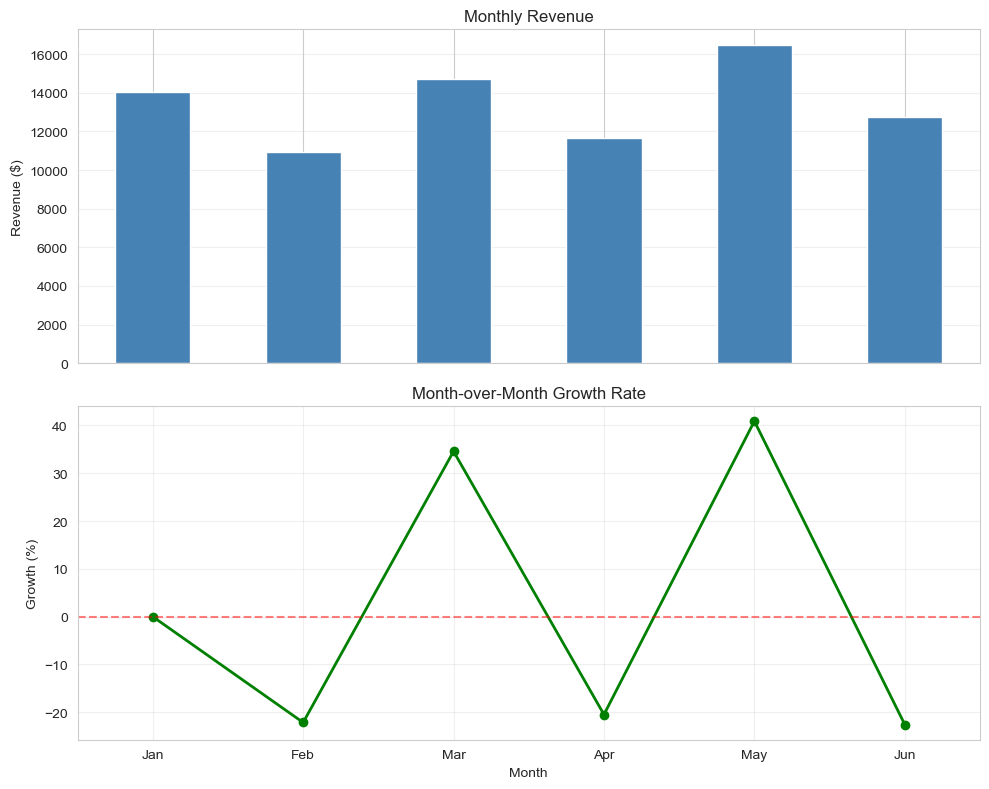

In [36]:
# Solution 11
# First, define month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Calculate monthly revenue
monthly_revenue = df.groupby('month')['purchase_amount'].sum().reindex(month_order)
print("Monthly Revenue:")
print(monthly_revenue.round(2))

# Calculate MoM growth
mom_growth = monthly_revenue.pct_change() * 100
mom_growth.iloc[0] = 0  # Set first month to 0 or np.nan

print("\nMonth-over-Month Growth Rate (%):")
print(mom_growth.round(2))

# Create a DataFrame for better display
result_df = pd.DataFrame({
    'Total_Revenue': monthly_revenue,
    'MoM_Growth_%': mom_growth
}).round(2)
print("\nCombined Results:")
print(result_df)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
monthly_revenue.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(axis='y', alpha=0.3)

mom_growth.plot(kind='line', ax=axes[1], marker='o', color='green', linewidth=2)
axes[1].set_title('Month-over-Month Growth Rate')
axes[1].set_ylabel('Growth (%)')
axes[1].set_xlabel('Month')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Expected: DataFrame showing revenue and growth rate for each month